### Name = David Lamboni
### UID = 118794853

## Filtering and Cleaning The Data

In [1]:
import pandas as pd
import re

nba_players = pd.read_csv("nba_players.csv") # Information on NBA players in the league
cbb_rankings = pd.read_csv("cbb.csv") # College rankings

# Filtering the NBA players to the relvant columns
filtered_nbaPlayers = nba_players[['player_name', 'college', 'draft_year', 'draft_round', 'draft_number']].dropna() # filtered and cleaned our df
filtered_nbaPlayers

,player_name,college,draft_year,draft_round,draft_number
0,Randy Livingston,Louisiana State,1996,2,42
1,Gaylon Nickerson,Northwestern Oklahoma,1994,2,34
2,George Lynch,North Carolina,1993,1,12
3,George McCloud,Florida State,1989,1,7
4,George Zidek,UCLA,1995,1,22
...,...,...,...,...,...
12839,Joel Embiid,Kansas,2014,1,3
12840,John Butler Jr.,Florida State,Undrafted,Undrafted,Undrafted
12841,John Collins,Wake Forest,2017,1,19
12842,Jericho Sims,Texas,2021,2,58


In [2]:
# Filtering CBB rankings to our relevant columns
filtered_cbbRanks = cbb_rankings[['TEAM', 'CONF', 'POSTSEASON', 'YEAR']].dropna() # cleaning our df to work with rows with no missing values
filtered_cbbRanks

,TEAM,CONF,POSTSEASON,YEAR
0,North Carolina,ACC,2ND,2016
1,Wisconsin,B10,2ND,2015
2,Michigan,B10,2ND,2018
3,Texas Tech,B12,2ND,2019
4,Gonzaga,WCC,2ND,2017
...,...,...,...,...
3586,Montana St.,BSky,R68,2024
3587,Stetson,ASun,R64,2024
3588,Howard,MEAC,R68,2024
3589,Grambling St.,SWAC,R64,2024


In [3]:
# Cleaning up our nba df so that the years match with our cbb dataset
cols = ["draft_round", "draft_number"]

# We want to normalize undrafted values as 0
filtered_nbaPlayers[cols] = (
    filtered_nbaPlayers[cols]
        .replace("Undrafted", 0)
)

filtered_nbaPlayers[cols] = (
    filtered_nbaPlayers[cols]
        .replace(r"(?i)undrafted", 0, regex=True)
)

# Replacing all values to 0, and converting our 3 columns to integers
for col in ["draft_year", "draft_round", "draft_number"]:
    filtered_nbaPlayers[col] = (
        pd.to_numeric(filtered_nbaPlayers[col], errors="coerce")
        .fillna(0)
        .astype(int)
    )

# This is our cleaned dataset, so we're only working with the values that we need
cleanNBA = filtered_nbaPlayers[filtered_nbaPlayers['draft_year'] >= 2013]

# For matching purposes, we want to check for the most oldest years for both new datasets
oldest_nba = cleanNBA['draft_year'].min()
oldest_cbb = filtered_cbbRanks['YEAR'].min()

print(f"Oldest nba year: {oldest_nba}") # match \
print(f"Oldest cbb year: {oldest_cbb}") # match /

cleanNBA

Oldest nba year: 2013
Oldest cbb year: 2013


,player_name,college,draft_year,draft_round,draft_number
7641,Isaiah Canaan,Murray State,2013,2,34
7646,Gorgui Dieng,Louisville,2013,1,21
7653,Glen Rice,Georgia Tech,2013,2,35
7664,Erik Murphy,Florida,2013,2,49
7672,Jamaal Franklin,San Diego State,2013,2,41
...,...,...,...,...,...
12836,Joe Harris,Virginia,2014,2,33
12838,Joe Wieskamp,Iowa,2021,2,41
12839,Joel Embiid,Kansas,2014,1,3
12841,John Collins,Wake Forest,2017,1,19


## Normalizing College Names and Merging

In [4]:
import pandas as pd
import re

cleanNBA = cleanNBA.copy()
filtered_cbbRanks = filtered_cbbRanks.copy()

# Canonical normalization
def normalize_college(name):
    if pd.isna(name):
        return None

    name = name.lower().strip()
    name = re.sub(r"[^\w\s]", "", name)

    # remove institutional words
    name = re.sub(r"\bthe\b", "", name)
    name = re.sub(r"\buniversity of\b", "", name)
    name = re.sub(r"\buniversity\b", "", name)
    name = re.sub(r"\bcollege\b", "", name)

    # canonical expansions
    name = re.sub(r"\bst\b", "state", name)
    name = re.sub(r"\bsaint\b", "st", name)

    # normalize whitespace
    name = re.sub(r"\s+", " ", name).strip()

    return name


# Apply normalization (use .loc)
cleanNBA.loc[:, "college_norm"] = cleanNBA["college"].apply(normalize_college)
filtered_cbbRanks.loc[:, "college_norm"] = (
    filtered_cbbRanks["TEAM"].apply(normalize_college)
)

# Manual fixes
college_fixes = {
    "unc": "north carolina",
    "uconn": "connecticut",
    "usc": "southern california",
    "ucla": "california los angeles",
    "lsu": "louisiana state",
}

cleanNBA.loc[:, "college_norm"] = cleanNBA["college_norm"].replace(college_fixes)
filtered_cbbRanks.loc[:, "college_norm"] = (
    filtered_cbbRanks["college_norm"].replace(college_fixes)
)

# Ensure years are numeric
cleanNBA.loc[:, "draft_year"] = pd.to_numeric(
    cleanNBA["draft_year"], errors="coerce"
)
filtered_cbbRanks.loc[:, "YEAR"] = pd.to_numeric(
    filtered_cbbRanks["YEAR"], errors="coerce"
)


# Lookup tables, for matching conferences
# A) Year-specific ranking lookup
rank_lookup = (
    filtered_cbbRanks[["college_norm", "YEAR", "POSTSEASON"]]
    .dropna(subset=["college_norm", "YEAR"])
    .drop_duplicates(subset=["college_norm", "YEAR"])
)

# B) College-level conference lookup
college_conf_map = (
    filtered_cbbRanks[["college_norm", "CONF"]]
    .dropna(subset=["college_norm", "CONF"])
    .drop_duplicates(subset=["college_norm"])
)

# Merge rankings by college + draft year
merged = cleanNBA.merge(
    rank_lookup,
    left_on=["college_norm", "draft_year"],
    right_on=["college_norm", "YEAR"],
    how="left"
)

# Encode unranked years
merged.loc[:, "POSTSEASON"] = merged["POSTSEASON"].fillna("Unranked")
merged.loc[:, "ranked_college"] = merged["POSTSEASON"].ne("Unranked")

# Merge conference by college only
merged = merged.merge(
    college_conf_map,
    on="college_norm",
    how="left"
)

# True non-NCAA fallback
merged.loc[:, "CONF"] = merged["CONF"].fillna("Unranked / Non-NCAA")

# Verification to ensure columns are matched
still_unmatched = merged[
    (merged["CONF"] == "Unranked / Non-NCAA") &
    (merged["college_norm"].isin(college_conf_map["college_norm"]))
][["college", "college_norm"]].drop_duplicates()

# Final clean dataset
merged_clean = merged.drop(columns=["college_norm", "YEAR"])

merged_clean.to_csv("final_dataset.csv", index=False)
merged_clean


,player_name,college,draft_year,draft_round,draft_number,POSTSEASON,ranked_college,CONF
0,Isaiah Canaan,Murray State,2013,2,34,Unranked,False,OVC
1,Gorgui Dieng,Louisville,2013,1,21,Champions,True,BE
2,Glen Rice,Georgia Tech,2013,2,35,Unranked,False,ACC
3,Erik Murphy,Florida,2013,2,49,E8,True,SEC
4,Jamaal Franklin,San Diego State,2013,2,41,R32,True,MWC
...,...,...,...,...,...,...,...,...
1830,Joe Harris,Virginia,2014,2,33,S16,True,ACC
1831,Joe Wieskamp,Iowa,2021,2,41,R32,True,B10
1832,Joel Embiid,Kansas,2014,1,3,R32,True,B12
1833,John Collins,Wake Forest,2017,1,19,R68,True,ACC


## Creating Our Visualizations to Answer Our Questions

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("final_dataset.csv")

# keep only drafted players (recommended for draft-round questions)
df_drafted = df[df["draft_round"] > 0].copy()

# indicators
df_drafted["first_round"] = (df_drafted["draft_round"] == 1)
df_drafted["ranked_school"] = (df_drafted["POSTSEASON"] != "Unranked")


In [6]:
# Question 1
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_drafted["ranked_school"], df_drafted["first_round"])
chi2, p, dof, expected = chi2_contingency(ct)

print(ct)
print("Chi-square:", chi2)
print("p-value:", p)


first_round    False  True 
ranked_school              
False            246    298
True             385    867
Chi-square: 34.20801652717108
p-value: 4.952452006400568e-09


POSTSEASON x FirstRound p-value: 6.958799950696111e-15


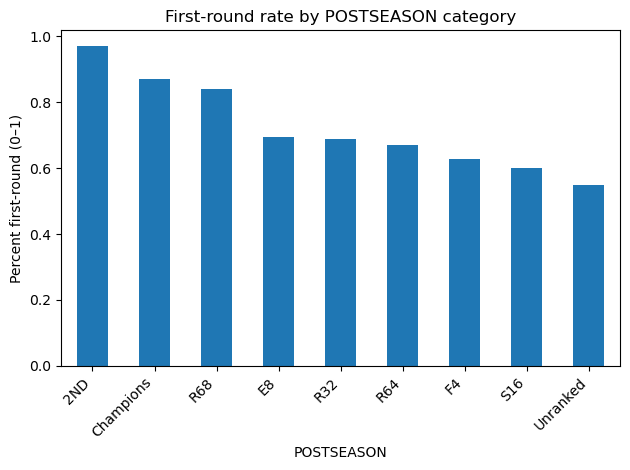

In [7]:
# Question 1 Contd
ct2 = pd.crosstab(df_drafted["POSTSEASON"], df_drafted["first_round"])
chi2_2, p_2, dof_2, _ = chi2_contingency(ct2)
print("POSTSEASON x FirstRound p-value:", p_2)

rate = (df_drafted.groupby("POSTSEASON")["first_round"]
        .mean()
        .sort_values(ascending=False))

plt.figure()
rate.plot(kind="bar")
plt.ylabel("Percent first-round (0–1)")
plt.title("First-round rate by POSTSEASON category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


draft_round
1    298
2    246
Name: count, dtype: int64
draft_round
1    0.547794
2    0.452206
Name: count, dtype: float64


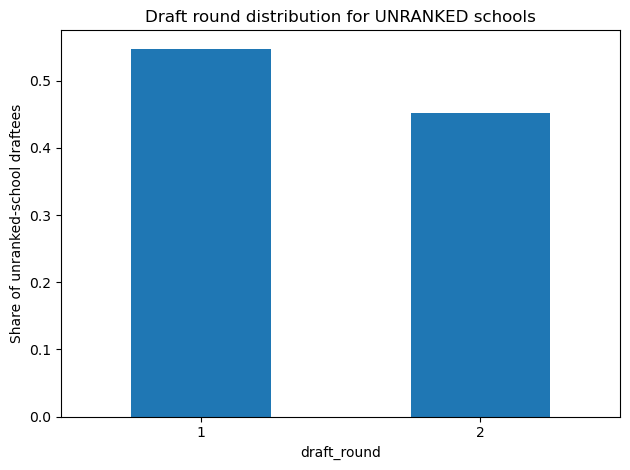

In [8]:
# Question 2
unranked = df_drafted[df_drafted["POSTSEASON"] == "Unranked"].copy()

round_counts = unranked["draft_round"].value_counts().sort_index()
round_pct = round_counts / round_counts.sum()

print(round_counts)
print(round_pct)

plt.figure()
round_pct.plot(kind="bar")
plt.ylabel("Share of unranked-school draftees")
plt.title("Draft round distribution for UNRANKED schools")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


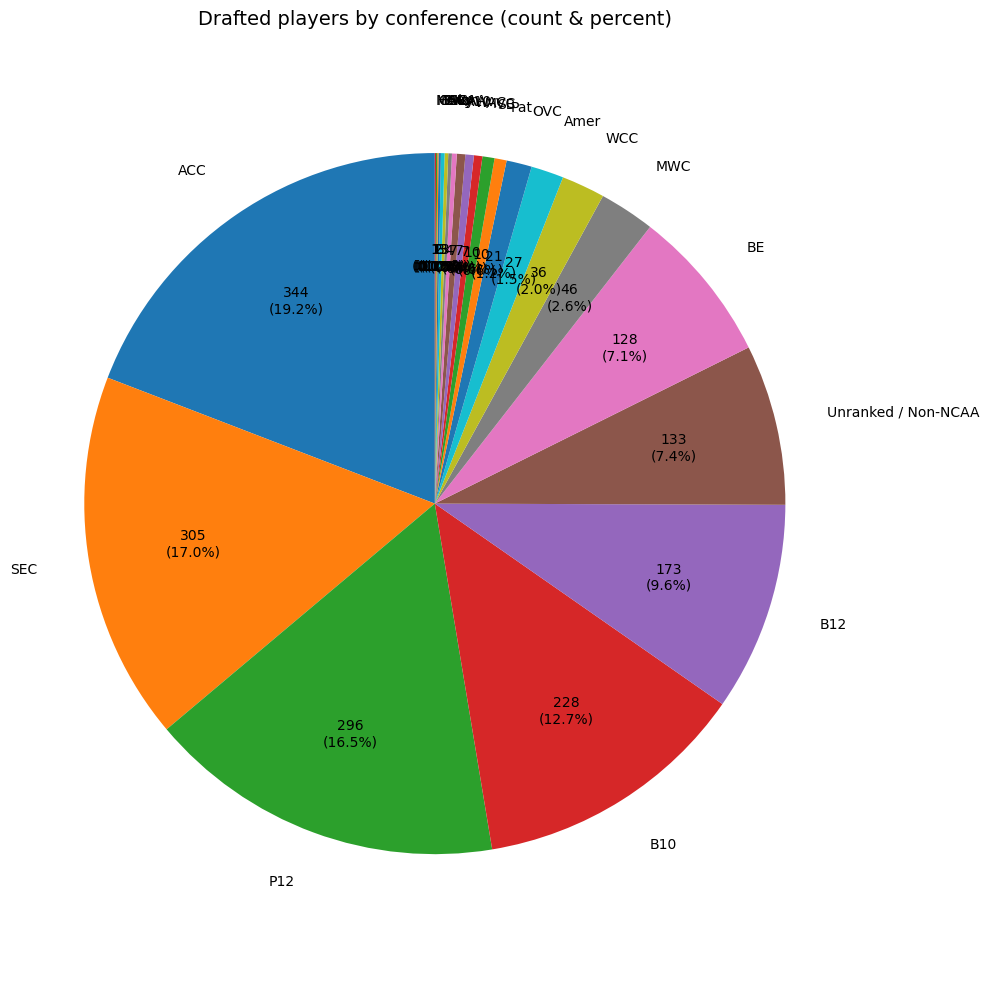

In [9]:
conf_counts = df_drafted["CONF"].value_counts()
conf_pct = (conf_counts / conf_counts.sum()) * 100

# Custom autopct function to show count + percent
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return "%d\n(%.1f%%)" % (count, pct)
    return inner

plt.figure(figsize=(10, 10))  # make chart larger

plt.pie(
    conf_pct,
    labels=conf_pct.index,
    autopct=autopct_format(conf_counts.values),
    startangle=90,
    labeldistance=1.15,   # push labels outward
    pctdistance=0.7       # move numbers inward
)

plt.title("Drafted players by conference (count & percent)", fontsize=14)
plt.axis("equal")  # keep pie circular
plt.tight_layout()
plt.show()


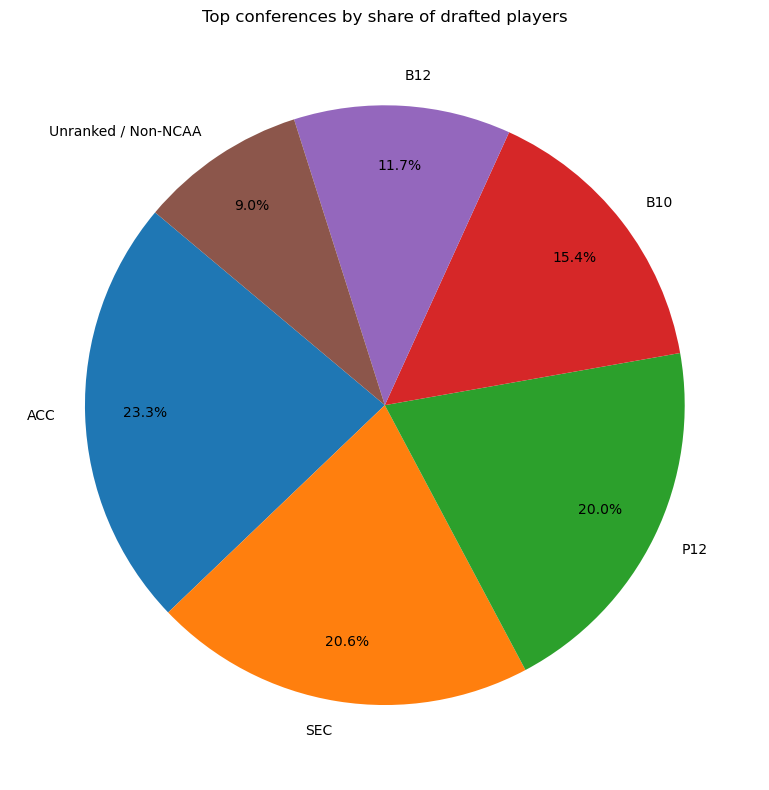

In [10]:
# Question 4
top_n = 6
top_conf_pct = conf_pct.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8, 8))
top_conf_pct.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.8
)
plt.ylabel("")  # remove y-label for pie chart
plt.title("Top conferences by share of drafted players")
plt.tight_layout()
plt.show()

## Regression Model and Visualization

Optimization terminated successfully.
         Current function value: 0.102352
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                drafted   No. Observations:                 1835
Model:                          Logit   Df Residuals:                     1832
Method:                           MLE   Df Model:                            2
Date:                Thu, 18 Dec 2025   Pseudo R-squ.:                0.005108
Time:                        22:28:27   Log-Likelihood:                -187.82
converged:                       True   LL-Null:                       -188.78
Covariance Type:            nonrobust   LLR p-value:                    0.3812
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.6950      0.301     12.274      0.000       3.105       4.285
ranked_college   

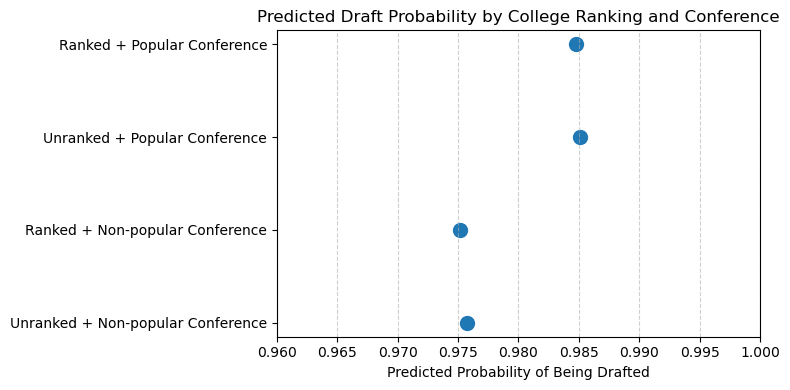

In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load the final dataset

df = pd.read_csv("final_dataset.csv")

# Create variables for regression

# Outcome: whether the player was drafted into the NBA
df["drafted"] = (df["draft_round"] > 0).astype(int)

# Indicator: ranked college
df["ranked_college"] = (df["POSTSEASON"] != "Unranked").astype(int)

# Indicator: popular basketball conferences
popular_confs = ["SEC", "ACC", "Pac-12", "Big Ten", "Big 12"]
df["popular_conf"] = df["CONF"].isin(popular_confs).astype(int)

# Keep only rows needed for the model
df_model = df.dropna(subset=["drafted", "ranked_college", "popular_conf"])

# Logistic regression
logit_model = smf.logit(
    formula="drafted ~ ranked_college + popular_conf",
    data=df_model
).fit()

print(logit_model.summary())

# Odds ratios (interpretation)
odds_ratios = np.exp(logit_model.params)
print("\nOdds Ratios:")
print(odds_ratios)

# Predicted probabilities by scenario
pred_df = pd.DataFrame({
    "ranked_college": [0, 1, 0, 1],
    "popular_conf": [0, 0, 1, 1]
})

pred_df["predicted_probability"] = logit_model.predict(pred_df)

pred_df["Scenario"] = [
    "Unranked + Non-popular Conference",
    "Ranked + Non-popular Conference",
    "Unranked + Popular Conference",
    "Ranked + Popular Conference"
]

print("\nPredicted probabilities by scenario:")
print(pred_df[["Scenario", "predicted_probability"]])

# Use your existing predicted probabilities
viz_df = pred_df.copy()

plt.figure(figsize=(8, 4))
plt.scatter(
    viz_df["predicted_probability"],
    viz_df["Scenario"],
    s=100
)

plt.xlabel("Predicted Probability of Being Drafted")
plt.title("Predicted Draft Probability by College Ranking and Conference")
plt.xlim(0.96, 1.00)  # zoom in to show subtle differences
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
